# Notebook to plot the results from RANDOM FOREST REGRESSION

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

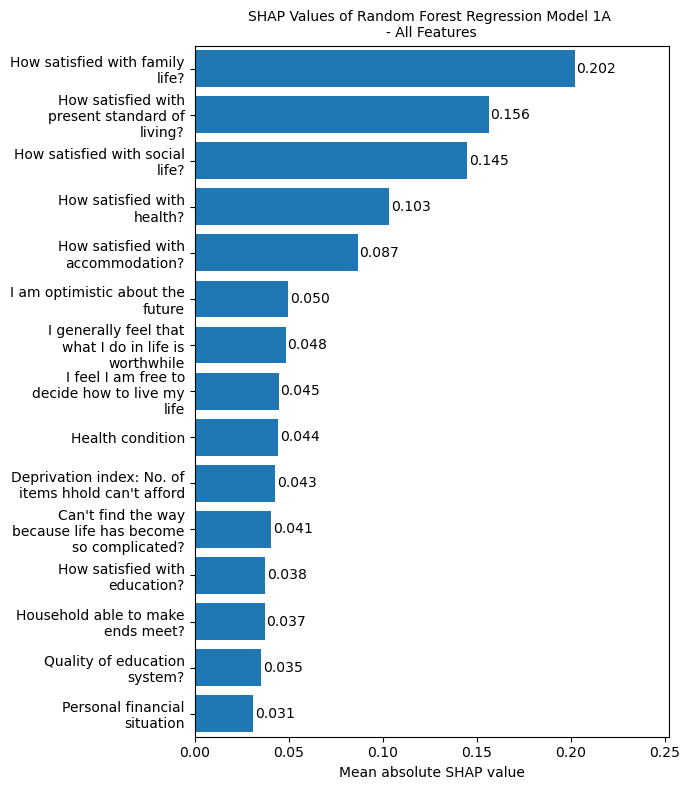

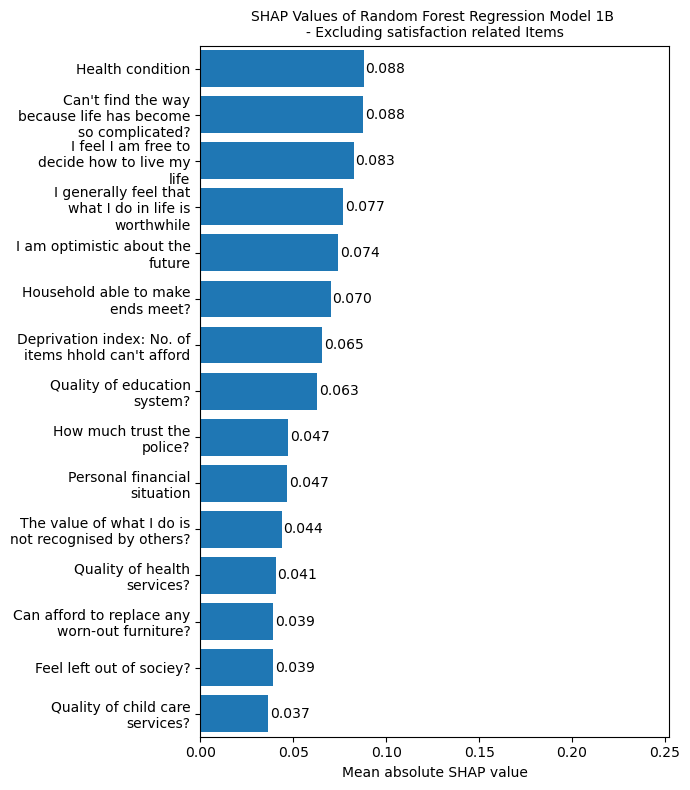

In [15]:
# Load Data
df_1A = pd.read_csv("Results/shap_results_1A_optimized.csv")
df_1B = pd.read_csv("Results/shap_results_1B_optimized.csv")
# df_2A = pd.read_csv("Results/shap_results_2A_optimized.csv")
# df_2B = pd.read_csv("Results/shap_results_2B_optimized.csv")

def plot_shap_large(df, title, max_questions=None):
    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    #plt.figure(figsize=(7, n * 0.5))
    plt.figure(figsize=(7, 8))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title 
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_1A["Value"].max(),
        df_1B["Value"].max(),
        # df_2A["Value"].max(),
        # df_2B["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)
    
    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_1A, "SHAP Values of Random Forest Regression Model 1A \n- All Features", max_questions=15)
plot_shap_large(df_1B, "SHAP Values of Random Forest Regression Model 1B \n- Excluding satisfaction related Items", max_questions=15)
# plot_shap_large(df_2A, "RF: Model 2A opt. – SHAP > 0.01",max_questions=10)
# plot_shap_large(df_2B, "RF: Model 2B opt. – SHAP > 0.01 w/o Satisfaction", max_questions=10)
plt.show()